Data Analytics III


1. Implement Simple Naïve Bayes classification algorithm using Python/R on iris.csv dataset.

    
2. Compute Confusion matrix to find TP, FP, TN, FN, Accuracy, Error rate, Precision, Recall
on the given dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score,
                             classification_report)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder


In [2]:
df = pd.read_csv("A3_Iris.csv")

In [3]:
df.head()

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [4]:
df.tail()

,sepal.length,sepal.width,petal.length,petal.width,variety
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica
149,5.9,3.0,5.1,1.8,Virginica


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal.length  150 non-null    float64
 1   sepal.width   150 non-null    float64
 2   petal.length  150 non-null    float64
 3   petal.width   150 non-null    float64
 4   variety       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [6]:
df.describe()

,sepal.length,sepal.width,petal.length,petal.width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [7]:
df.isnull().sum()

sepal.length    0
sepal.width     0
petal.length    0
petal.width     0
variety         0
dtype: int64

In [8]:
df.shape

(150, 5)

In [9]:
X = df[['sepal.length' , 'sepal.width' , 'petal.length' , 'petal.width']].values
Y = df['variety'].values

In [10]:
le = LabelEncoder()

In [11]:
Y_encoded = le.fit_transform(Y)

In [12]:
Y_encoded

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [13]:
x_train , x_test , y_train , y_test = train_test_split(X , Y_encoded , test_size=0.25 , random_state = 42)

In [14]:
from sklearn.naive_bayes import GaussianNB

In [15]:
model = GaussianNB()

In [16]:
model = model.fit(x_train , y_train)

In [17]:
y_pred = model.predict(x_test)

In [18]:
result = pd.DataFrame({
    "original y_test" : le.inverse_transform(y_test),
    "original y_pred" : le.inverse_transform(y_pred) ,
    "Comparison" : y_test == y_pred
})

In [19]:
result

,original y_test,original y_pred,Comparison
0,Versicolor,Versicolor,True
1,Setosa,Setosa,True
2,Virginica,Virginica,True
3,Versicolor,Versicolor,True
4,Versicolor,Versicolor,True
5,Setosa,Setosa,True
6,Versicolor,Versicolor,True
7,Virginica,Virginica,True
8,Versicolor,Versicolor,True
9,Versicolor,Versicolor,True


In [20]:
result['Comparison'].value_counts()

Comparison
True    38
Name: count, dtype: int64

In [21]:
accuracy_score(y_test , y_pred)

1.0

In [22]:
precision_score(y_test , y_pred , average="macro")

1.0

In [23]:
recall_score(y_test , y_pred , average = 'macro')

1.0

In [24]:
cm = confusion_matrix(y_test , y_pred)

In [25]:
# TP = cm[0][0]
# FP = cm[1][0]
# FN = cm[0][1]
# TN = cm[1][1]

In [26]:
cm

array([[15,  0,  0],
       [ 0, 11,  0],
       [ 0,  0, 12]])

In [27]:
# total = TP+FP+TN+FN

In [28]:
accuracy = accuracy_score(y_test , y_pred)

In [29]:
error_rate = 1-accuracy

In [30]:
precision =precision_score(y_test , y_pred, average = 'macro')

In [31]:
recall = recall_score(y_test , y_pred, average = 'macro')

In [32]:
metrices = ['Accuracy' , 'Error Rate' , 'Precision' , 'Recall']
values = [accuracy , error_rate , precision , recall]

<Axes: >

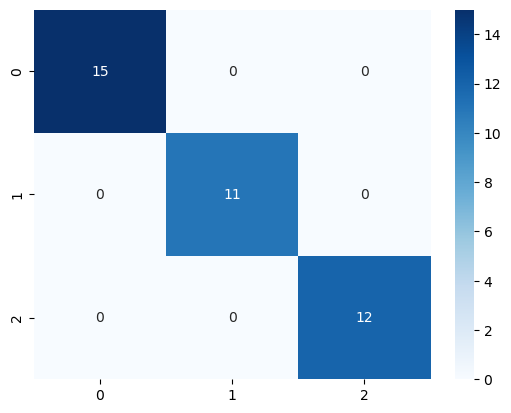

In [33]:
sns.heatmap(cm ,annot = True, fmt='d' , cmap='Blues')  #we can add the xticklabels and yticklabels

<BarContainer object of 4 artists>

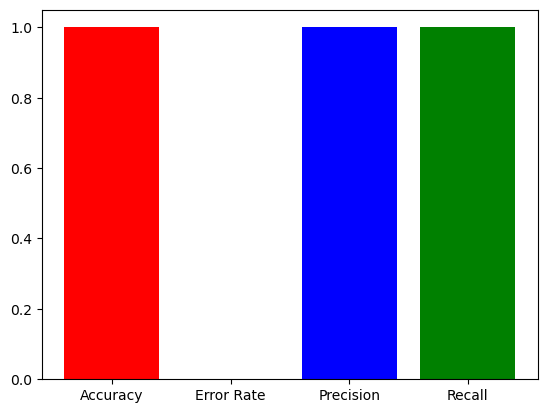

In [34]:
plt.bar(metrices , values , color=['red' ,'yellow', 'blue' , 'green'])